In [ ]:
# ACCESING THE DRIVE(DATA HANDLING)----------
import os
# List all files in MyDrive
os.listdir('/content/drive/MyDrive')

['Unit 2.pdf',
 'Unit 2.gdoc',
 'model QB.docx.iswr',
 'Unit 4.pdf.iswr',
 'Unit 3.pdf.iswr',
 'Unit 5.pdf.iswr',
 'WC_QB RMK-converted.pdf.iswr',
 'Classroom',
 'SQL_QUERIES.pptx',
 'I year Japanese Learning students 2022-26.xlsx',
 'UNIT 5 digital content (1).pptx',
 'DAY 2.docx',
 'RECORD_AI[1].docx',
 '111622201087 (1).pdf',
 '111622201087.pdf',
 'Basic_unix.pdf',
 'Basic_unix.gdoc',
 'Essay.gdoc',
 "Team Creation - EDII's Hackathon -2023-24.pdf",
 'Colab Notebooks',
 'Demystifying Networking.pdf',
 'IMG-20241002-WA0014.jpg',
 'TEAM 13-BOYS.pptx',
 '111621102108 - PRASHANTHINI S (2).gdoc',
 'Corizo.pdf',
 'day1.pdf',
 'DAY2.pdf',
 'Maven+Market+CSV+Files.zip',
 'Coding - Problem statements to practise-20250220T030952Z-001.zip',
 'SIMULATION CHECK procedure (1).docx',
 'Code.zip',
 'Disease and symptoms dataset.csv',
 'R M K College of Engineering and Technology.xlsb',
 'bg.zip',
 'FINAL.zip']

In [ ]:
# DATA HANDLING---------------
import zipfile
import os

# Correct path (exactly as shown in os.listdir output)
dataset_path = '/content/drive/MyDrive/FINAL.zip'

# Double-check file exists before unzipping
if os.path.exists(dataset_path):
    print("File found ✅")
    with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
        zip_ref.extractall('/content/dataset')
    print("Extraction completed ✅")
    print(os.listdir('/content/dataset'))
else:
    print("File not found ❌")


File found ✅
Extraction completed ✅
['FairFace']


Found images: ['4189.jpg', '3391.jpg', '13250.jpg', '54795.jpg', '40794.jpg']


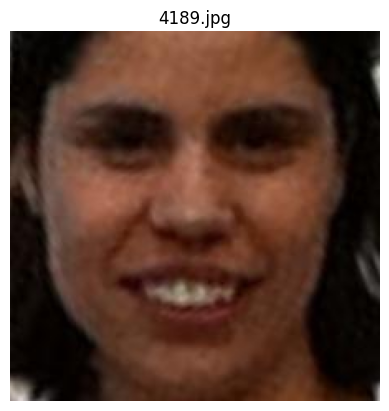

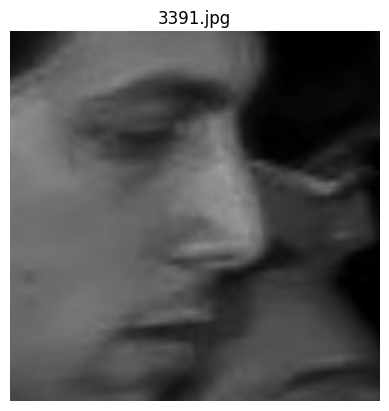

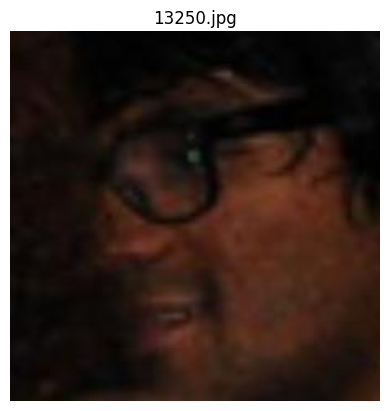

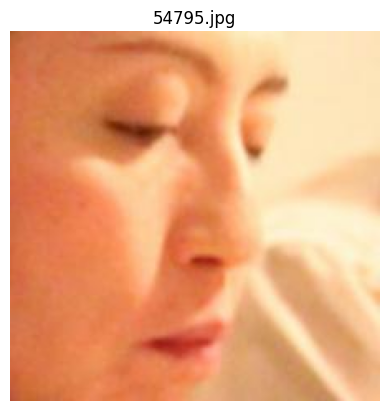

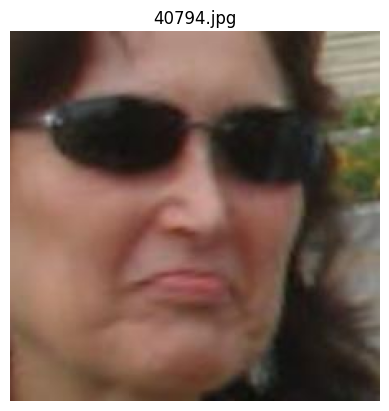

In [ ]:
#VERYFING THE EXTRACTION------------------
import os
import matplotlib.pyplot as plt
import cv2

# Path to train images
train_path = '/content/dataset/FairFace/train'

# List first 5 images
img_files = [f for f in os.listdir(train_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:5]

print("Found images:", img_files[:5])

# Display them
for img_name in img_files:
    img_path = os.path.join(train_path, img_name)
    img = cv2.imread(img_path)[..., ::-1]  # BGR → RGB
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")
    plt.show()


In [ ]:
# VERIFICATION AND READING CSV--------------------------------------
import pandas as pd

# Load the training labels
train_labels = pd.read_csv('/content/dataset/FairFace/train_labels.csv')

# Show first few rows
print(train_labels.head())

# Check if one of your sample images exists in the CSV
sample_img = '4189.jpg'
print(train_labels[train_labels['file'] == sample_img])


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset/FairFace/train_labels.csv'

In [ ]:
# Check properly for your sample image
sample_img = 'train/4189.jpg'
print(train_labels[train_labels['file'] == sample_img])


                file    age  gender             race  service_test
4188  train/4189.jpg  20-29  Female  Latino_Hispanic          True


In [ ]:
#COVERSION AGE RANGES TO MIDPOINT FOR ML TRAINING--------------------------------
import pandas as pd
import os

# Load CSV
train_labels = pd.read_csv('/content/dataset/FairFace/train_labels.csv')

# Convert age ranges to numbers (midpoint)
def convert_age(age_str):
    age_str = str(age_str).strip()
    if '-' in age_str:  # e.g. "30-39"
        low, high = age_str.split('-')
        return (int(low) + int(high)) / 2
    elif '+' in age_str:  # e.g. "70+"
        return 70
    elif "more" in age_str.lower():  # e.g. "more than 70"
        return 70
    else:
        try:
            return int(age_str)  # in case it's a single number
        except:
            return None  # unknown / invalid entries

# Apply conversion
train_labels['age_num'] = train_labels['age'].apply(convert_age)

# Add absolute path for each image
base_path = '/content/dataset/FairFace'
train_labels['filepath'] = train_labels['file'].apply(lambda x: os.path.join(base_path, x))

print(train_labels.head())
print("\nUnique ages (numeric):", train_labels['age_num'].unique()[:10])

          file    age  gender        race  service_test  age_num  \
0  train/1.jpg  50-59    Male  East Asian          True     54.5   
1  train/2.jpg  30-39  Female      Indian         False     34.5   
2  train/3.jpg    3-9  Female       Black         False      6.0   
3  train/4.jpg  20-29  Female      Indian          True     24.5   
4  train/5.jpg  20-29  Female      Indian          True     24.5   

                                filepath  
0  /content/dataset/FairFace/train/1.jpg  
1  /content/dataset/FairFace/train/2.jpg  
2  /content/dataset/FairFace/train/3.jpg  
3  /content/dataset/FairFace/train/4.jpg  
4  /content/dataset/FairFace/train/5.jpg  

Unique ages (numeric): [54.5 34.5  6.  24.5 44.5 14.5 64.5  1.  70. ]


In [ ]:
import pandas as pd

# Load labels
train_labels = pd.read_csv('/content/dataset/FairFace/train_labels.csv')
val_labels   = pd.read_csv('/content/dataset/FairFace/val_labels.csv')

# Count images
print("Train images:", len(train_labels))
print("Val images:  ", len(val_labels))
print("Total images:", len(train_labels) + len(val_labels))


Train images: 86744
Val images:   10954
Total images: 97698


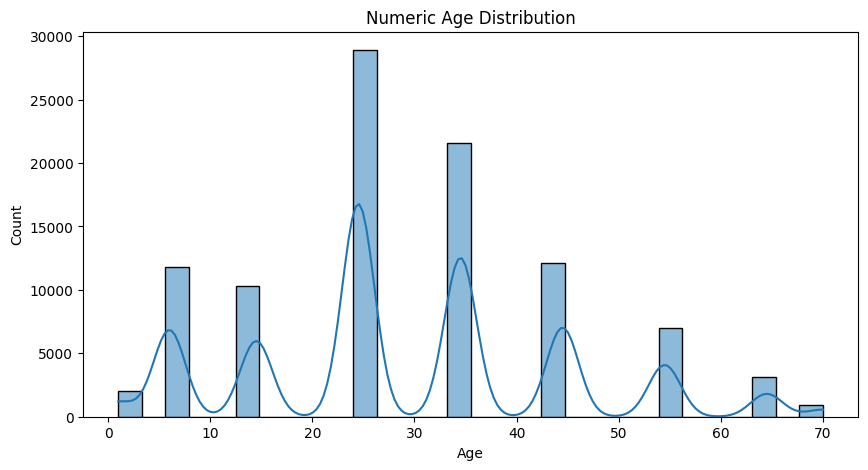

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Combine train + val labels into one DataFrame
all_labels = pd.concat([train_labels, val_labels], ignore_index=True)

# Convert age to numeric (if not already)
all_labels['age_num'] = all_labels['age'].apply(convert_age)

# Plot age distribution
plt.figure(figsize=(10,5))
sns.histplot(all_labels['age_num'], bins=30, kde=True)
plt.title("Numeric Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
import os
from PIL import Image

class FairFaceDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, age_mapping=None):
        """
        Args:
            csv_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
            age_mapping (dict): Dictionary to map age groups to class indices.
        """
        self.labels_frame = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
        self.age_mapping = age_mapping

    def __len__(self):
        return len(self.labels_frame)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_name = os.path.join(self.root_dir, self.labels_frame.iloc[idx, 0])
        image = Image.open(img_name).convert('RGB')

        # Calculate age_class using the age_mapping and the 'age' column
        age_group = self.labels_frame.iloc[idx]['age']
        age_class = self.age_mapping.get(age_group) # Use .get for safer lookup


        if self.transform:
            image = self.transform(image)

        # Return the age_class as a tensor
        return image, torch.tensor(age_class)

In [ ]:

# Create the mapping directly from the unique age groups in the dataset
unique_age_groups = sorted(all_labels['age'].unique())
age2class = {age: idx for idx, age in enumerate(unique_age_groups)}


# Image transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Dataset loaders
train_data = FairFaceDataset(csv_file='/content/dataset/FairFace/train_labels.csv',
                           root_dir='/content/dataset/FairFace',
                           transform=train_transform,
                           age_mapping=age2class)

val_data = FairFaceDataset(csv_file='/content/dataset/FairFace/val_labels.csv',
                         root_dir='/content/dataset/FairFace',
                         transform=val_transform,
                         age_mapping=age2class)


train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_data, batch_size=64, shuffle=False, num_workers=4)

print("Train dataset size:", len(train_data))
print("Validation dataset size:", len(val_data))
print("Age to class mapping:", age2class)

Train dataset size: 86744
Validation dataset size: 10954
Age to class mapping: {'0-2': 0, '10-19': 1, '20-29': 2, '3-9': 3, '30-39': 4, '40-49': 5, '50-59': 6, '60-69': 7, 'more than 70': 8}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
import torch.nn as nn
import torchvision.models as models

# Number of age classes (from your mapping)
num_classes = 15

model = models.resnet18(pretrained=True)

# Replace the final layer with our classifier
model.fc = nn.Linear(model.fc.in_features, num_classes)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()  # good for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [ ]:
import torch

from tqdm import tqdm

def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10, save_path="best_model.pth"):
    best_val_acc = 0.0  # to save only the best model

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # ---------- Training ----------
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc="Training", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = 100 * correct / total

        # ---------- Validation ----------
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validating", leave=False):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= val_total
        val_acc = 100 * val_correct / val_total

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")

        # ---------- Save Best Model ----------
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(f"✅ Model saved at {save_path} (Val Acc: {val_acc:.2f}%)")

    print("\nTraining complete. Best Val Acc:", best_val_acc)


In [ ]:
# 1. Train and save best model
train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    save_path="best_model.pth"  # ensure same path is used
)

# 2. Load the saved weights later (for evaluation/inference)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)   # make sure model is on correct device
model.eval()

print("✅ Model loaded and ready for evaluation/inference")



Epoch 1/10


Training:   6%|▋         | 87/1356 [00:39<09:36,  2.20it/s]Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x78022b3e96c0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
^^    ^self._shutdown_workers()
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
^^    ^if w.is_alive():

   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
     assert self._parent_pid == os.getpid(), 'can only test a child process' 
       ^^ ^ ^  ^^ ^  ^ ^^^^^^^^
^  File "/usr/lib/python3.12/multiproce

Train Loss: 1.2861 | Train Acc: 46.04%
Val   Loss: 1.1970 | Val   Acc: 49.58%
✅ Model saved at best_model.pth (Val Acc: 49.58%)

Epoch 2/10


Training:   4%|▎         | 48/1356 [00:22<07:23,  2.95it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78022b3e96c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
Training:   4%|▎         | 50/1356 [00:23<08:37,  2.52it/s]^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Training:   4%|▍         | 55/1356 [00:25<07:10,  3.02it/s]<function _MultiProcessingDataLoaderIter.__del__ at 0x78022b3e96c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664,

Train Loss: 1.1530 | Train Acc: 50.71%
Val   Loss: 1.1635 | Val   Acc: 50.79%
✅ Model saved at best_model.pth (Val Acc: 50.79%)

Epoch 3/10


...

Train Loss: 0.9529 | Train Acc: 58.98%
Val   Loss: 1.0523 | Val   Acc: 55.41%
✅ Model saved at best_model.pth (Val Acc: 55.41%)

Epoch 9/10


Training:   2%|▏         | 33/1356 [00:15<09:04,  2.43it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78022b3e96c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
Training:   3%|▎         | 35/1356 [00:16<09:53,  2.23it/s]^^^^^^^^^^^^^
AssertionError: can only test a child process
Training:   3%|▎         | 36/1356 [00:16<08:33,  2.57it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78022b3e96c0>
Exception ignored in: Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/to

Train Loss: 0.9306 | Train Acc: 59.92%
Val   Loss: 1.0632 | Val   Acc: 54.25%

Epoch 10/10


Training:   2%|▏         | 25/1356 [00:12<09:48,  2.26it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78022b3e96c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
Training:   2%|▏         | 26/1356 [00:12<08:23,  2.64it/s]self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78022b3e96c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
     

Train Loss: 0.9046 | Train Acc: 61.04%
Val   Loss: 1.0836 | Val   Acc: 53.86%

Training complete. Best Val Acc: 55.413547562534234
✅ Model loaded and ready for evaluation/inference


In [ ]:
import torch
from PIL import Image
from torchvision import transforms
from google.colab import files  # only if running in Colab

# --- Upload image ---
uploaded = files.upload()  # select an image from your computer
image_path = list(uploaded.keys())[0]  # take the first uploaded file

# --- Preprocessing (must match training/validation pipeline) ---
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # resize for ResNet input
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# --- Load and preprocess image ---
img = Image.open(image_path).convert("RGB")  # ensure 3 channels
img_tensor = val_transform(img).unsqueeze(0).to(device)  # add batch dim & send to device

# --- Prediction ---
model.eval()
with torch.no_grad():
    outputs = model(img_tensor)            # forward pass
    _, predicted = torch.max(outputs, 1)   # get class index
    pred_class = predicted.item()

# --- Map class index back to age group ---
class2age = {v: k for k, v in age2class.items()}  # invert mapping
pred_age_group = class2age[pred_class]

print(f"✅ Predicted Age Group: {pred_age_group}")


Saving Screenshot 2025-08-25 145155.png to Screenshot 2025-08-25 145155.png
✅ Predicted Age Group: 20-29


In [ ]:

from google.colab import files

# Download the saved best model to your device
files.download("best_model.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ls -lh /content | grep best_model.pth


-rw-r--r-- 1 root root  43M Aug 25 08:17 best_model.pth


In [ ]:
from google.colab import files
files.download("/content/best_model.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# --- Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Imports ---
import torch
from torchvision import models, transforms
from PIL import Image
from google.colab import files

# --- Setup device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Define model (same as training) ---
# num_classes = 17  # make sure this matches training
num_classes = 15 # Corrected based on training
model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model.to(device)

# --- Load trained weights ---
# model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth", map_location=device))
model.load_state_dict(torch.load("/content/best_model.pth", map_location=device)) # Corrected path
model.eval()

# --- Define preprocessing ---
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# --- Upload image ---
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# --- Preprocess image ---
img = Image.open(image_path).convert("RGB")
img_tensor = val_transform(img).unsqueeze(0).to(device)

# --- Predict ---
with torch.no_grad():
    outputs = model(img_tensor)
    _, predicted = torch.max(outputs, 1)
    pred_class = predicted.item()

# --- Class mapping (adjust for your 15 classes) ---
# Example: if your dataset has 17 age groups, fill them here
# class2age = {
#     0: "0-2", 1: "3-5", 2: "6-9", 3: "10-14", 4: "15-19",
#     5: "20-24", 6: "25-29", 7: "30-34", 8: "35-39",
#     9: "40-44", 10: "45-49", 11: "50-54", 12: "55-59",
#     13: "60-64", 14: "65-69", 15: "70-74", 16: "75+"
# }

# Using the age2class mapping from earlier cells
# Make sure this mapping is consistent with the one used during training
age_bins = ['0-4','5-9','10-14','15-19','20-24','25-29',
            '30-34','35-39','40-44','45-49','50-54',
            '55-59','60-64','65-69','70+']

age2class = {age: idx for idx, age in enumerate(age_bins)}
class2age = {v: k for k, v in age2class.items()} # Invert mapping


# --- Final result ---
pred_age_group = class2age.get(pred_class, "Unknown")
print(f"✅ Predicted Age Group: {pred_age_group}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


IndexError: list index out of range